<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_5_x_credit_card_fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Credit Card Fraud Detection Dataset

**Data Source:** [OpenML](https://www.openml.org/d/1597) - Original dataset from Kaggle, originally collected by Worldline and the Machine Learning Group at Université Libre de Bruxelles (ULB)

**Outcome Variable:** `Class` - Binary: 0 = legitimate transaction, 1 = fraudulent transaction

**Features:**
- **Time:** Seconds elapsed between this transaction and the first transaction in the dataset
- **Amount:** Transaction amount
- **V1-V28:** Anonymized features obtained via PCA transformation (original sensitive features were transformed to protect customer identities)

The dataset contains 284,807 transactions with only 492 frauds (0.172% fraud rate), making it extremely imbalanced.

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.datasets import fetch_openml
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_curve, auc,
    precision_recall_curve, make_scorer
)

In [4]:
# get the data, create a dataframe
creditcard = fetch_openml(name='creditcard', version=1, as_frame=True)
df = creditcard.frame

In [5]:
# check data (missing, dtype) - this has already been cleaned up
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype   
---  ------  --------------   -----   
 0   V1      284807 non-null  float64 
 1   V2      284807 non-null  float64 
 2   V3      284807 non-null  float64 
 3   V4      284807 non-null  float64 
 4   V5      284807 non-null  float64 
 5   V6      284807 non-null  float64 
 6   V7      284807 non-null  float64 
 7   V8      284807 non-null  float64 
 8   V9      284807 non-null  float64 
 9   V10     284807 non-null  float64 
 10  V11     284807 non-null  float64 
 11  V12     284807 non-null  float64 
 12  V13     284807 non-null  float64 
 13  V14     284807 non-null  float64 
 14  V15     284807 non-null  float64 
 15  V16     284807 non-null  float64 
 16  V17     284807 non-null  float64 
 17  V18     284807 non-null  float64 
 18  V19     284807 non-null  float64 
 19  V20     284807 non-null  float64 
 20  V21     284807 non-null  f

In [6]:
# Class is being inferred as a catgeory.
# If it were properly 0, 1 it should be an int.
# Need to investigate and fix.
print(df['Class'].unique())

# They are strings. Let's fix this.
df['Class'] = df['Class'].astype('int')
print(df['Class'].unique())

['0', '1']
Categories (2, object): ['0', '1']
[0 1]


In [7]:
# verifying extreme imbalance
df['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


In [8]:
# get descriptives for features
df.iloc[:,:-1].describe().T.iloc[:,1:].round(2).sort_index().head(10)

,mean,std,min,25%,50%,75%,max
Amount,88.35,250.12,0.00,5.60,22.00,77.16,25691.16
V1,0.00,1.96,-56.41,-0.92,0.02,1.32,2.45
V10,0.00,1.09,-24.59,-0.54,-0.09,0.45,23.75
V11,0.00,1.02,-4.80,-0.76,-0.03,0.74,12.02
V12,-0.00,1.00,-18.68,-0.41,0.14,0.62,7.85
V13,0.00,1.00,-5.79,-0.65,-0.01,0.66,7.13
V14,0.00,0.96,-19.21,-0.43,0.05,0.49,10.53
V15,0.00,0.92,-4.50,-0.58,0.05,0.65,8.88
V16,0.00,0.88,-14.13,-0.47,0.07,0.52,17.32
V17,-0.00,0.85,-25.16,-0.48,-0.07,0.40,9.25


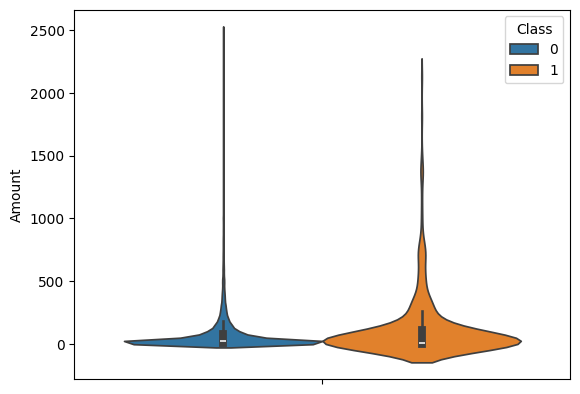

In [9]:
# check out amount as it relates to class
sns.violinplot(data=df[df['Amount'] < 2500], y='Amount', hue='Class')
plt.show()

## Prepare the Data for XGBoost

* **Numeric targets?** XGBoost requires numeric encodings for the labels (binary encoding in this case). This is already done. 0 is not-fraud, 1 is fraud.
* **Categorical Features?** XGBoost can now handle categorical data directly, so you don't have to one-hot encode anymore. With this particular data set there are no categorical features to worry about anyway.
* **Stratified split?** Our imbalance is so extreme it is absolutely essential we use stratified splits.


In [10]:
from sklearn.model_selection import train_test_split

X = df.iloc[:,:-1]
y = df['Class']

# 3. Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
                                      X,
                                      y,
                                      test_size=0.3,
                                      random_state=42,
                                      stratify=y)

print(f"Original features: {X.shape[1]}")
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set class ratio: {y_test.astype(int).mean():.1%} bad, {(1-y_test.astype(int).mean()):.1%} good")

Original features: 29
Training set size: 199364
Test set class ratio: 0.2% bad, 99.8% good


## Decisions for intial XGBoost Models
* `scale_pos_weight` We have a dramtic imbalance, so we need to tell XGBoost to pay attention to the minority class. We do this by calculating `scale_pos_weight` in advance and passing that calculated ratio as an argument into XGBoost.
* `n_estimators`, `max_depth`, `learning_rate` We can grid search these later, for now we are just using pretty standard values.
* `eval_metric` Our typical choices are:
  * `error`
  * `logloss` which will give us probabilites
  * `auc` or area under the curve which uses balance between true positive and false positives (used for imbalanced datasets)
  * `prauc` assesses precisions and recall strictly for the minority class, used for highly imbalanced datasets    


In [13]:
import xgboost as xgb

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train.astype(int) == 0).sum() / (y_train.astype(int) == 1).sum()

# Instantiate and train the XGBoost model
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
)
model.fit(X_train, y_train.astype(int))

# Get probabilities for the positive class (Default)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print('Model training complete.')

Model training complete.


## Feature Importance
For this dataset the features are almost entirely not human comprehensible, so we can skip this.

## Confusion Matrix

--- Confusion Matrix Breakdown ---
True Negatives  (TN) — Correctly Identified Non-Default: 85072
True Positives  (TP) — Correctly Identified Default:  125
False Positives (FP) — False Alarms / Type I:     223
False Negatives (FN) — Missed Defaults / Type II: 23


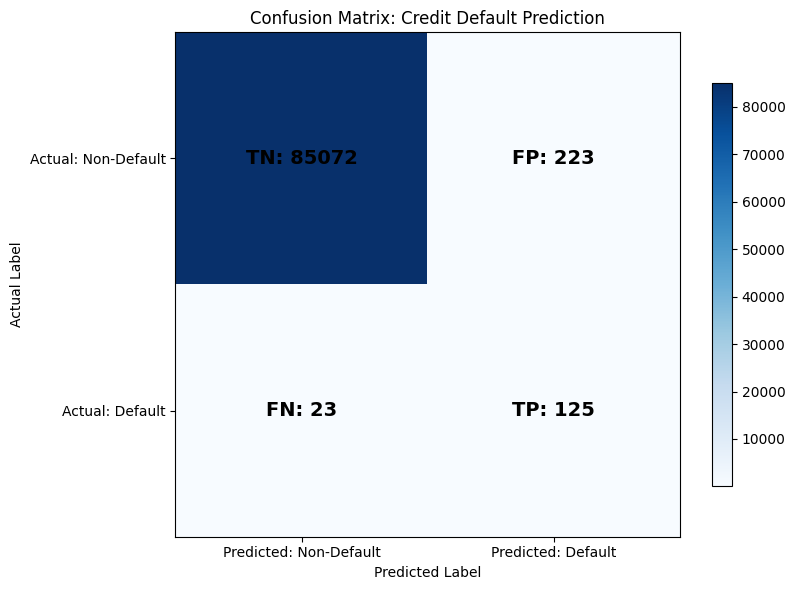

In [14]:
# Generate the matrix --- You do not need to know how this code works
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"--- Confusion Matrix Breakdown ---")
print(f"True Negatives  (TN) — Correctly Identified Non-Default: {tn}")
print(f"True Positives  (TP) — Correctly Identified Default:  {tp}")
print(f"False Positives (FP) — False Alarms / Type I:     {fp}")
print(f"False Negatives (FN) — Missed Defaults / Type II: {fn}")

# Visualize with labeled cells
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: Non-Default', 'Predicted: Default'])
ax.set_yticklabels(['Actual: Non-Default', 'Actual: Default'])
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Confusion Matrix: Credit Default Prediction')

# Add labels with both count and terminology
labels = [
    [f'TN: {tn}', f'FP: {fp}'],
    [f'FN: {fn}', f'TP: {tp}']
]
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i][j], ha='center', va='center', fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

In [15]:
print(classification_report(y_test, y_pred, target_names=['Not-Fraud (0)', 'Fraud (1)']))

               precision    recall  f1-score   support

Not-Fraud (0)       1.00      1.00      1.00     85295
    Fraud (1)       0.36      0.84      0.50       148

     accuracy                           1.00     85443
    macro avg       0.68      0.92      0.75     85443
 weighted avg       1.00      1.00      1.00     85443



## Summary so far...
We've got an untuned model with a macro  precision of .68, macro recall of .92, and macro f1 score of .75. We have a lot more false positives than false negatives. Our model is too "trigger happy", that is, willing to call something fraud when its not. This will annoy legitimate customers. The credit card company is likely to want us to do better.

(Note: One thing we could do here is back off on the `scale_pos_weight` ratio to make the model less aggressive in identifying fraudulent cases).

## Probabilities and the Decision Threshold

Note! I've log scaled the y-axis so we can see the details better.

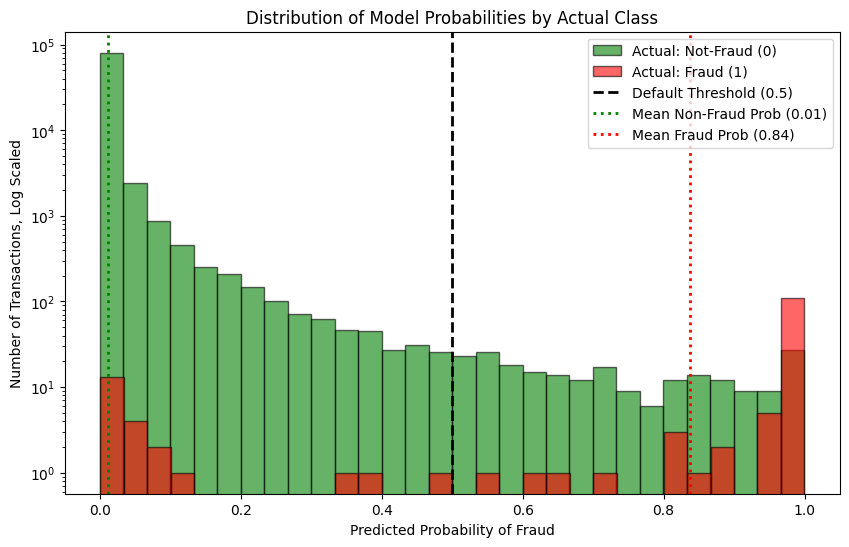


Overlap Analysis:
  15.5% of actual fraudulent transactions scored below 0.5 (missed cases / false negatives)
  0.3% of legitimate transctions scored above 0.5 (false alarms / false positives)


In [16]:
# Calculate overlap statistics
fn_rate = ((y_proba[y_test==1] < 0.5).sum() / (y_test==1).sum()) * 100
fp_rate = ((y_proba[y_test==0] >= 0.5).sum() / (y_test==0).sum()) * 100

fig, ax = plt.subplots(figsize=(10, 6))

# Plot overlapping histograms by actual class
ax.hist(y_proba[y_test==0], bins=30, alpha=0.6, label='Actual: Not-Fraud (0)', color='green', edgecolor='black')
ax.hist(y_proba[y_test==1], bins=30, alpha=0.6, label='Actual: Fraud (1)', color='red', edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Default Threshold (0.5)')

# Add mean probability lines
mean_good = y_proba[y_test==0].mean()
mean_bad = y_proba[y_test==1].mean()
ax.axvline(x=mean_good, color='green', linestyle=':', linewidth=2, label=f'Mean Non-Fraud Prob ({mean_good:.2f})')
ax.axvline(x=mean_bad, color='red', linestyle=':', linewidth=2, label=f'Mean Fraud Prob ({mean_bad:.2f})')

ax.set_xlabel('Predicted Probability of Fraud')
ax.set_ylabel('Number of Transactions, Log Scaled')
ax.set_title('Distribution of Model Probabilities by Actual Class')
ax.set_yscale('log') # Changed to y-axis log scale
ax.legend()
plt.show()

print(f"\nOverlap Analysis:")
print(f"  {fn_rate:.1f}% of actual fraudulent transactions scored below 0.5 (missed cases / false negatives)")
print(f"  {fp_rate:.1f}% of legitimate transctions scored above 0.5 (false alarms / false positives)")

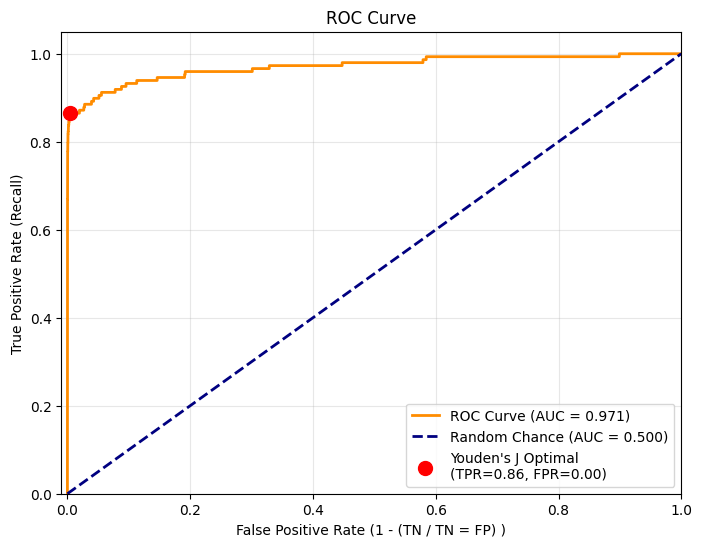

AUC = 0.971

Interpretation: If you randomly pick one fraudulent transaction

and one legitimates transaction, the model correctly ranks the 

fradulent transaction as higher-risk 97.1% of the time.


In [17]:
# Calculate the ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Find Youden's J optimal point for annotation
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_tpr = tpr[best_idx]
best_fpr = fpr[best_idx]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance (AUC = 0.500)')

# Mark the Youden's J optimal point
plt.scatter([best_fpr], [best_tpr], color='red', s=100, zorder=5, label=f"Youden's J Optimal\n(TPR={best_tpr:.2f}, FPR={best_fpr:.2f})")

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - (TN / TN = FP) )')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC = {roc_auc:.3f}")
print(f"\nInterpretation: If you randomly pick one fraudulent transaction")
print(f"\nand one legitimates transaction, the model correctly ranks the ")
print(f"\nfradulent transaction as higher-risk {roc_auc*100:.1f}% of the time.")

In [18]:
# Calculate J for all thresholds on the ROC curve
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"--- Youden's J Results ---")
print(f"Best Threshold: {best_threshold:.3f}")
print(f"Max J-Score:    {j_scores[best_idx]:.3f}")
print(f"TPR (Recall) at this point: {tpr[best_idx]:.3f}")
print(f"FPR at this point: {fpr[best_idx]:.3f}")

# Compare to default 0.5
y_default = (y_proba >= 0.5).astype(int)
from sklearn.metrics import recall_score, precision_score
default_tpr = recall_score(y_test, y_default)
default_fpr = ((y_default == 1) & (y_test == 0)).sum() / (y_test == 0).sum()
print(f"\n--- For Comparison: Default Threshold (0.5) ---")
print(f"TPR (Recall): {default_tpr:.3f}")
print(f"FPR:          {default_fpr:.3f}")

--- Youden's J Results ---
Best Threshold: 0.343
Max J-Score:    0.860
TPR (Recall) at this point: 0.865
FPR at this point: 0.005

--- For Comparison: Default Threshold (0.5) ---
TPR (Recall): 0.845
FPR:          0.003


Not much difference here between Youden's and the default threshold in terms of performance.

### Problems with the ROC Curve

Important Note! Why should we ignore the AUC for this dataset? It is way too optimistic due to the imbalance. ROC AUC relies on the False Positive Rate (FPR), caluculated as FP / (FP + TN).

Because our TN (True Negatives) are massive (97% of our data), the denominator in this formula becomes huge. Even if your model generates many False Positives the FPR will remain deceptively small.



## Looking at Precision Recall Instead

The Precision Recall curve completely ignores those 97% True Negatives. It only looks at the "Fraud" class. It plots Precision (How many alerts were real?) vs. Recall (How many frauds did we catch?). If you start flagging too many innocent people to catch fraud, your Precision will tank, and the curve will sag.

## F-Beta Score
Sometimes you don't want a balanced model. You might care more about one type of error than the other. The F-Beta score is a formula that lets you "dial in" that preference by adjusting the (beta) value.
  * F1 Score (beta = 1): Treats Precision and Recall as equally important. This is the standard "balanced" math.
  * F2 Score (beta = 2): Weights Recall higher than Precision. Business Logic: "I care more about catching fraud than I do about accidental declines. Let's find every crook, even if we annoy some people."
  * F0.5 Score (beta = 0.5): Weights Precision higher than Recall. Business Logic: "The credit card company is losing too many customers! Only flag a transaction if you are extremely sure its fraud."


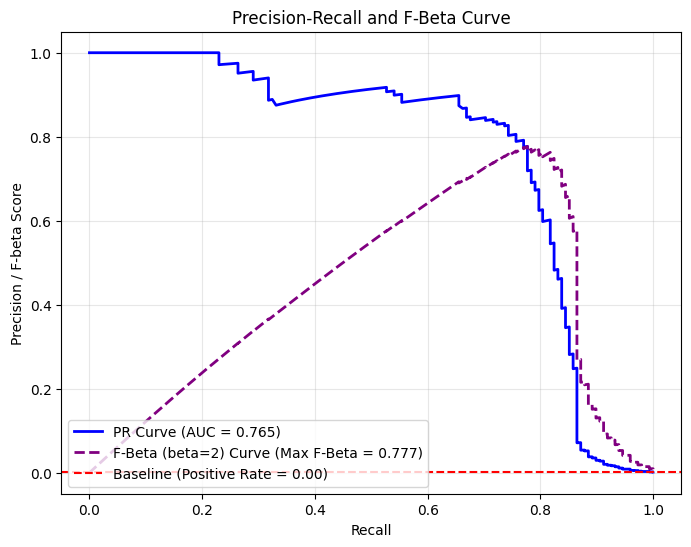

PR AUC = 0.765
Baseline (random guessing precision) = 0.002

Max F-Beta (beta=2) Score = 0.777
  at Recall = 0.777
  at Precision = 0.777
  at Threshold = 0.938


In [19]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)  # Note: order is (x, y)
pos_rate = y_test.mean()

# Calculate F-beta scores
beta = 2 # Prioritize recall (beta > 1)
f_beta_scores = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)

# Handle potential division by zero (where precision + recall is 0)
f_beta_scores = np.nan_to_num(f_beta_scores)

# Find the optimal threshold for F-beta
best_f_beta_idx = np.argmax(f_beta_scores)
best_f_beta = f_beta_scores[best_f_beta_idx]
best_precision = precision[best_f_beta_idx]
best_recall = recall[best_f_beta_idx]
best_threshold_f_beta = thresholds[best_f_beta_idx]

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.plot(recall, f_beta_scores, color='purple', lw=2, linestyle='--', label=f'F-Beta (beta={beta}) Curve (Max F-Beta = {best_f_beta:.3f})')
plt.axhline(y=pos_rate, color='red', linestyle='--', label=f'Baseline (Positive Rate = {pos_rate:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision / F-beta Score')
plt.title('Precision-Recall and F-Beta Curve')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

print(f"PR AUC = {pr_auc:.3f}")
print(f"Baseline (random guessing precision) = {pos_rate:.3f}")
print(f"\nMax F-Beta (beta={beta}) Score = {best_f_beta:.3f}")
print(f"  at Recall = {best_recall:.3f}")
print(f"  at Precision = {best_precision:.3f}")
print(f"  at Threshold = {best_threshold_f_beta:.3f}")

* **Overall Performance:** Our model (76.5%) is performing hundreds of times better than random guessing. This show the model features have strong predictive power.
* **The High Threshold (0.938):**
Because we had so many False Positives at the default 0.5 threshold, we have to "crank up" the requirements to 93.8% certainty to get the best balance of errors.
* **Understanding F-Beta (Beta=2):** Beta = 2 means you are weighting Recall twice as heavily as Precision. If we use the F-Beta we are telling the model: "It is more important to catch the fraud (Recall) than it is to avoid annoying the customer (Precision)."
* **Finding a Sweet Spot:** It is a coincidence that your Recall, Precision, and F-score all hit 0.777 at this point. At this threshold, we are catching 78% of all fraud and 78% of your alerts are actually fraud.
* **Tradeoffs:** If we used F-beta we woulbd be  "trading" some recall (dropping from 0.92 to 0.78) to help clean up our False Positives.


In [ ]:
y_pred_fbeta = (y_proba >= best_threshold_f_beta).astype(int)
print(f"--- Classification Report with F-beta Optimal Threshold ({best_threshold_f_beta:.3f}) ---")
print(classification_report(y_test, y_pred_fbeta, target_names=['Not-Fraud (0)', 'Fraud (1)']))

So the F1-Beta allows us to balance precision and recall for the Fraud class. If the company wants to equalize the errors we could stop here, but its unlikely that two kinds of errors cost the company the same amount.

In [ ]:
test_thresholds = np.arange(0.3, 1.0, 0.05)
costs = []

for t in test_thresholds:
    y_t = (y_proba >= t).astype(int)
    fp = ((y_t == 1) & (y_test == 0)).sum()
    fn = ((y_t == 0) & (y_test == 1)).sum()
    total_cost = (fp * 100) + (fn * 450)
    costs.append(total_cost)

cost_optimal_idx = np.argmin(costs)
cost_optimal_threshold = test_thresholds[cost_optimal_idx]
min_cost = costs[cost_optimal_idx]

# Calculate cost at default 0.5
y_default = (y_proba >= 0.5).astype(int)
fp_default = ((y_default == 1) & (y_test == 0)).sum()
fn_default = ((y_default == 0) & (y_test == 1)).sum()
cost_default = (fp_default * 500) + (fn_default * 5000)

# Calculate cost at Youden's J threshold
y_youden = (y_proba >= best_threshold).astype(int)
fp_youden = ((y_youden == 1) & (y_test == 0)).sum()
fn_youden = ((y_youden == 0) & (y_test == 1)).sum()
cost_youden = (fp_youden * 500) + (fn_youden * 5000)

# Calculate cost at F-beta optimal threshold
y_fbeta = (y_proba >= best_threshold_f_beta).astype(int)
fp_fbeta = ((y_fbeta == 1) & (y_test == 0)).sum()
fn_fbeta = ((y_fbeta == 0) & (y_test == 1)).sum()
cost_fbeta = (fp_fbeta * 500) + (fn_fbeta * 5000)

plt.figure(figsize=(10, 5))
plt.plot(test_thresholds, costs, marker='o', color='crimson')
plt.axvline(x=cost_optimal_threshold, color='green', linestyle='--', label=f'Cost-Optimal ({cost_optimal_threshold:.2f})')
plt.axvline(x=0.5, color='black', linestyle=':', label=f'Default (0.50)')
plt.axvline(x=best_threshold, color='blue', linestyle='-.', label=f"Youden's J ({best_threshold:.2f})")
plt.axvline(x=best_threshold_f_beta, color='orange', linestyle='-', label=f"F-Beta Optimal ({best_threshold_f_beta:.2f})")
plt.xlabel('Threshold')
plt.ylabel('Total Estimated Cost ($)')
plt.title('Business-Optimal Threshold Selection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"--- Cost Comparison ---")
print(f"Default threshold (0.50):  ${cost_default:,.0f}")
print(f"Youden's J ({best_threshold:.2f}):       ${cost_youden:,.0f}")
print(f"F-Beta Optimal ({best_threshold_f_beta:.2f}):   ${cost_fbeta:,.0f}")
print(f"Cost-optimal ({cost_optimal_threshold:.2f}):  ${min_cost:,.0f}")
print(f"\nSavings vs. default:       ${cost_default - min_cost:,.0f}")

## Implications of Data Driven and Business Driven Thresholds

Our results show that the "optimal" thresholds calculated by standard statistical formulas would  cost the credit card company a small fortune.

* **Default (0.50) - 226,500:** Using the standard 0.5 threshold is costing the compnay nearly a quarter-million dollars. This threshold is likely causing a massive flood of False Positives that the model isn't being penalized enough for.
* **Youdens J (0.34) - 293,000:** This is our worst performer. Because Youdens J tries to maximize the balance between sensitivity and specificity, it actually lowered our threshold to 0.34. This invited even more False Positives into the system, increasing costs by almost 70k over the default.
* **F-Beta Optimal (0.94) - 181,500:** We previously saw that at 0.94, our Precision and Recall hit a "sweet spot" (0.77). By demanding higher certainty (94%) before flagging fraud, you slashed costs by over 45,000 compared to the default. This was a great step, but it still treated errors as unit-less stats rather than dollars.
* **Cost-optimal (0.95) - 18,300:** This is a 10x improvement over the default. It worked by explicitly telling the model that a False Positive costs 100 and a False Negative costs 450, the math found that the "safest" place for the business is at a 95% confidence threshold.
At this level, you are likely letting a few more small frauds slip through (False Negatives), but you have almost entirely eliminated the "Customer Friction" (False Positives) that was draining the budget in the other scenarios.

## Hyperparamter Tuning with Gridsearch
We've been using fairly default hyperparameters up to this point. Let's start looking at them systematically to see if we can improve out model.



In [32]:
# this takes ~5 minutes to run

# 1. Define the OBJECTIVE (This tells XGBoost HOW TO TRAIN)
def cost_weighted_objective(y_true, y_pred):
    """
    Custom loss function for XGBoost to optimize for dollar costs.
    y_pred here are raw logits (pre-sigmoid).
    """
    cost_fp = 100
    cost_fn = 450

    # Sigmoid to get probabilities
    p = 1.0 / (1.0 + np.exp(-y_pred))

    # Gradient and Hessian math
    grad = cost_fn * (p - 1.0) * y_true + cost_fp * p * (1.0 - y_true)
    hess = (cost_fn * y_true + cost_fp * (1.0 - y_true)) * (p * (1.0 - p))

    return grad, hess

# 2. Define the SCORER (This tells GridSearchCV HOW TO RANK results)
def total_cost_scorer(y_true, y_prob):
    """
    Uses the 0.95 threshold we found earlier to calculate total loss.
    """
    # y_prob is the probability of the positive class (fraud)
    y_pred = (y_prob >= 0.95).astype(int)

    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    # Return negative cost because GridSearchCV wants to "maximize" the score
    return -(fp * 100 + fn * 450)

# 3. Setup the Scorer and the Search
cost_scoring = make_scorer(total_cost_scorer, response_method='predict_proba')

grid = GridSearchCV(
    estimator=xgb.XGBClassifier(
        objective=cost_weighted_objective,
        tree_method='hist',      # Recommended for speed
        enable_categorical=True  # As we discussed earlier
    ),
    param_grid={
        'max_depth': [3, 5, 7],
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1]
    },
    scoring=cost_scoring,
    cv=3 # 3-fold cross validation
)

#4. Run the Search
grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring=make_scorer(total_cost_scorer, response_method='predict_proba'))

In [33]:
# Convert results to a dataframe
results_df = pd.DataFrame(grid.cv_results_)

# Sort by your cost score (highest is best, remember scorers are negative)
results_df = results_df.sort_values(by='mean_test_score', ascending=False).reset_index()

# Show only the important columns
cols_to_show = ['param_learning_rate', 'param_max_depth', 'param_n_estimators', 'mean_test_score', 'std_test_score', 'rank_test_score']

results_df[cols_to_show].head()


,param_learning_rate,param_max_depth,param_n_estimators,mean_test_score,std_test_score,rank_test_score
0,0.1,5,300,-12616.666667,948.976056,1
1,0.1,5,200,-13933.333333,1932.758535,2
2,0.1,7,200,-14050.000000,884.119147,3
3,0.1,7,300,-14166.666667,1119.771802,4
4,0.1,7,100,-14983.333333,1189.771220,5


## Nested Cross-Validation with Grid-Search

Since we haven't done cross-validation so far, we should be concerned that that our results won't apply to other train-test splits. To really be confident, we should run nested-cross validation when we conduct our grid search. The downside to this is it will take a very long time. However, if this were a real world scenario and we were working for a large credit card company our additional time would be well spent to be confident in our findings.


### Why this is different
* The Outer Loop (cross_val_score): It splits your data into 5 parts. For each part, it hands the other 4 parts to the Grid Search to train on.
* The Inner Loop (GridSearchCV): Inside those 4 parts, it does its own 3-fold split to find the best parameters.
* The Result: We get 5 separate scores. If these scores are wildy different, it means our tuning is unstable or our dataset is too small. If they are consistent, we can be very confident in that $18,300 estimate you found earlier.
* Warning on Time: Since you have 18 combinations in your grid, a 3-fold inner CV, and a 5-fold outer CV, you are now training 270 models.  




In [34]:
# this takes 32 minutes to run, so I'm putting it into a conditional
# if you want to run it flip the False to True

if False:
# if True:

  # 1. Define the OBJECTIVE (Unchanged)
  def cost_weighted_objective(y_true, y_pred):
      cost_fp, cost_fn = 100, 450
      p = 1.0 / (1.0 + np.exp(-y_pred))
      grad = cost_fn * (p - 1.0) * y_true + cost_fp * p * (1.0 - y_true)
      hess = (cost_fn * y_true + cost_fp * (1.0 - y_true)) * (p * (1.0 - p))
      return grad, hess

  # 2. Define the SCORER (Unchanged)
  def total_cost_scorer(y_true, y_prob):
      y_pred = (y_prob >= 0.95).astype(int)
      fp = np.sum((y_pred == 1) & (y_true == 0))
      fn = np.sum((y_pred == 0) & (y_true == 1))
      return -(fp * 100 + fn * 450)

  cost_scoring = make_scorer(total_cost_scorer, response_method='predict_proba')

  # 3. Setup Nested CV Structure
  # Inner CV: Used to find the best hyperparameters
  inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

  # Outer CV: Used to estimate the true performance (generalization error)
  outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

  # Define the Inner Search
  grid_search = GridSearchCV(
      estimator=xgb.XGBClassifier(
          objective=cost_weighted_objective,
          tree_method='hist',
          enable_categorical=True
      ),
      param_grid={
          'max_depth': [3, 5, 7],
          'n_estimators': [100, 200, 300],
          'learning_rate': [0.01, 0.1]
      },
      scoring=cost_scoring,
      cv=inner_cv
  )

  # 4. Run Nested CV
  # This executes the inner search multiple times (once for each outer fold)
  nested_scores = cross_val_score(grid_search, X, y, cv=outer_cv, scoring=cost_scoring)

  print(f"Nested CV Cost Scores (Negative $): {nested_scores}")
  print(f"Mean Cost Score: {nested_scores.mean():.2f}")
  print(f"Standard Deviation: {nested_scores.std():.2f}")

Nested CV Cost Scores (Negative $): [-11000  -7500 -12800 -12000 -10100]
Mean Cost Score: -10680.00
Standard Deviation: 1832.38


### Nested Cv Results for Discussion
`Nested CV Cost Scores (Negative $): [-11000  -7500 -12800 -12000 -10100]`

`Mean Cost Score: -10680.00`

`Standard Deviation: 1832.38`

Nested CV is designed to tell us how well our tuning process works, not to give us a single final model. Because the inner loop runs 5 different times (once for each outer fold), it actually finds 5 different sets of "best" parameters.

The results above represent the unbiased dollar cost of our fraud strategy when tested on data the model has never seen.

What these number mean in practical terms:
1. Consistent "Real World" Performance:

      * The five numbers in the brackets are the total costs incurred in each of your 5 outer test folds.
          * The Best Case: -7,500
          * The Worst Case: -12,800
          * The Meaning: Even in our "worst" fold, you are still only losing ~13k. This is significantly better than our original "Default" cost of 226,500.
2. High Reliability (Low Standard Deviation)
      * A Standard Deviation of 1,832 on a mean of 10,680 is quite low (about 17%).
      Interpretation: Your model is stable. It isn't just getting "lucky" on specific parts of the data. You can confidently tell the credit card company: "We expect to lose roughly 10,700 per period, give or take 2,000."
3. Our Tuning Worked
      * Our earlier Cost-optimal estimate was 18,300. Your Nested CV mean is 10,680. The hyperparameter tuning (GridSearch) actually found a way to save you an additional 7,600 over your untuned "optimal threshold" model.
4. How to explain "Negative" to stakeholders
      * Since we used a negative scorer (because scikit-learn always wants to "maximize" a value), wejust flip the sign for our presentation.
      Total Expected Cost: $10,680

Final comparison to Baseline: You are moving from a 226,500 loss to a 10,680 loss. Total Savings: 215,820 (a 95% reduction in costs).



### How to get the final "Ideal" parameters
To get the actual parameters you will use in production, you must run the GridSearch one last time on your entire dataset (or your full training set).


In [35]:
# 1. Run the search on the FULL dataset to get the final production model
grid_search.fit(X, y)

# 2. Now we can see the "Ideal" parameters
print("Ideal Parameters:", grid_search.best_params_)

# 3. And get the final model
final_model = grid_search.best_estimator_

# 4. Save the model - This is what would get used in production
final_model.get_booster().save_model("fraud_model_v1.json")

Ideal Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}


`Ideal Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}`

We didn't do much of a grid search here. We could further explore by looking at lower learning rates and higher numbers of estimators.

## Final thoughts on this process:

* Nested CV gives us the "unbiased" truth: "On average, this tuning method saves us $X amount."
* Full Fit gives you the "production" tool: "Now that I trust the method, use all available data to build the absolute best version of that tool."